In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
train_data = pd.read_excel(r"C:\22134028  SUSHANK\Flight fare\Data_Train.xlsx")

In [8]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [9]:
type(train_data)

pandas.DataFrame

In [10]:
train_data.shape

(10683, 11)

# DATA CLEANING

In [11]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [12]:
train_data = train_data.dropna()

In [13]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [14]:
train_data[train_data.duplicated(keep = False)].sort_values(by = train_data.columns.tolist())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
...,...,...,...,...,...,...,...,...,...,...,...
2870,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,4273
1535,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
3711,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
2634,Vistara,24/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,5403


In [15]:
train_data = train_data.drop_duplicates()

In [16]:
train_data[train_data.duplicated(keep = False)].sort_values(by = train_data.columns.tolist())


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [17]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10462 non-null  str  
 1   Date_of_Journey  10462 non-null  str  
 2   Source           10462 non-null  str  
 3   Destination      10462 non-null  str  
 4   Route            10462 non-null  str  
 5   Dep_Time         10462 non-null  str  
 6   Arrival_Time     10462 non-null  str  
 7   Duration         10462 non-null  str  
 8   Total_Stops      10462 non-null  str  
 9   Additional_Info  10462 non-null  str  
 10  Price            10462 non-null  int64
dtypes: int64(1), str(10)
memory usage: 980.8 KB


###  Data Feature Engineering : Extract Day,Month & Year

In [18]:
data = train_data.copy()

In [19]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [20]:
data.dtypes


Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [21]:
data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"])

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\3109116361.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"])


In [22]:
data["Date_of_Journey"].dtypes

dtype('<M8[us]')

In [23]:
data["Journey_Day"] = data["Date_of_Journey"].dt.day
data["Journey_Month"] = data["Date_of_Journey"].dt.month
data["Journey_Year"] = data["Date_of_Journey"].dt.year

In [24]:
data["Dep_Time_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_Time_minute"] = pd.to_datetime(data["Dep_Time"]).dt.minute

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\2146132657.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Dep_Time_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour
C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\2146132657.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Dep_Time_minute"] = pd.to_datetime(data["Dep_Time"]).dt.minute


In [25]:
data["Arrival_Time_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_Time_minute"] = pd.to_datetime(data["Arrival_Time"]).dt.minute

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\3642545560.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Arrival_Time_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour
C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\3642545560.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Arrival_Time_minute"] = pd.to_datetime(data["Arrival_Time"]).dt.minute


In [26]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15


###  Analyse

In [27]:
def flight_dep_time(x):
    if x>4 and x<=8:
        return "Early Morning"
    elif x>8 and x<=12:
        return "Morning"
    elif x>12 and x<=16:
        return "Noon"
    elif x>16 and x<=20:
        return "Evening"
    elif x>20 and x<=24:
          return "Night"
    else:
        return "Late Night"

In [28]:
data["Dep_Time_hour"].apply(flight_dep_time)

0                Night
1        Early Morning
2              Morning
3              Evening
4                 Noon
             ...      
10678          Evening
10679          Evening
10680    Early Morning
10681          Morning
10682          Morning
Name: Dep_Time_hour, Length: 10462, dtype: str

<Axes: xlabel='Dep_Time_hour'>

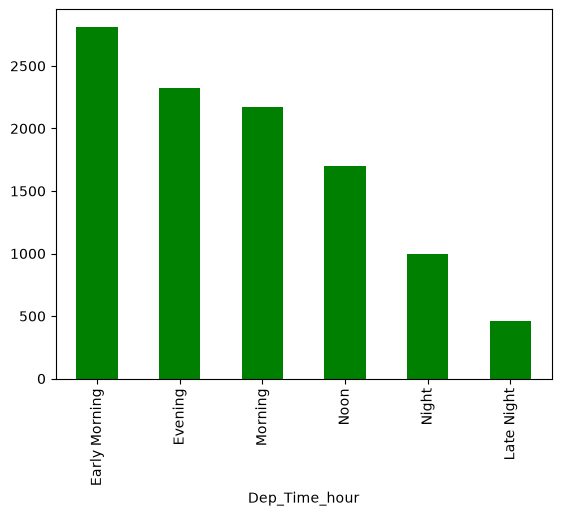

In [29]:
data["Dep_Time_hour"].apply(flight_dep_time).value_counts().plot(kind="bar",color = "green")

In [30]:
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import sys
print(sys.executable)

import nbformat
print(nbformat.__version__)
print(nbformat.__file__)

c:\22134028  SUSHANK\Flight fare\.venv\Scripts\python.exe
5.11.1
c:\22134028  SUSHANK\Flight fare\.venv\Lib\site-packages\nbformat\__init__.py


In [32]:
import plotly.express as px 

In [33]:
counts = data["Dep_Time_hour"].apply(flight_dep_time).value_counts().reset_index()
counts.columns = ["Dep_shift" , "Total_flights"]
counts

,Dep_shift,Total_flights
0,Early Morning,2814
1,Evening,2323
2,Morning,2170
3,Noon,1696
4,Night,995
5,Late Night,464


In [34]:
px.bar(data_frame = counts, x = "Dep_shift", y = "Total_flights")

In [35]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15


In [36]:
def preprocess_duration(x):
    if "h" not in x:
        x = "0h" + " " + x
    elif 'm' not in x:
        x = x + ' ' + '0m'
    return x

In [37]:
data['Duration'] = data['Duration'].apply(preprocess_duration)
data['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10462, dtype: str

In [38]:
data['Duration_hour'] = pd.to_timedelta(data['Duration']).dt.components.hours
data['Duration_minute'] = pd.to_timedelta(data['Duration']).dt.components.minutes

In [39]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25


In [40]:
cols_to_drop = ['Dep_Time', 'Arrival_Time', 'Duration', 'Date_of_Journey']

data.drop(cols_to_drop , axis = 1, inplace = True)

In [41]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Duration_hour', 'Duration_minute'],
      dtype='str')

In [42]:
data.dtypes

Airline                  str
Source                   str
Destination              str
Route                    str
Total_Stops              str
Additional_Info          str
Price                  int64
Journey_Day            int32
Journey_Month          int32
Journey_Year           int32
Dep_Time_hour          int32
Dep_Time_minute        int32
Arrival_Time_hour      int32
Arrival_Time_minute    int32
Duration_hour          int64
Duration_minute        int64
dtype: object

In [43]:
data['Duration_total_mins'] = data['Duration_hour']*60 + data['Duration_minute']

In [44]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_minute,Duration_total_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25,445


<Axes: xlabel='Duration_total_mins', ylabel='Price'>

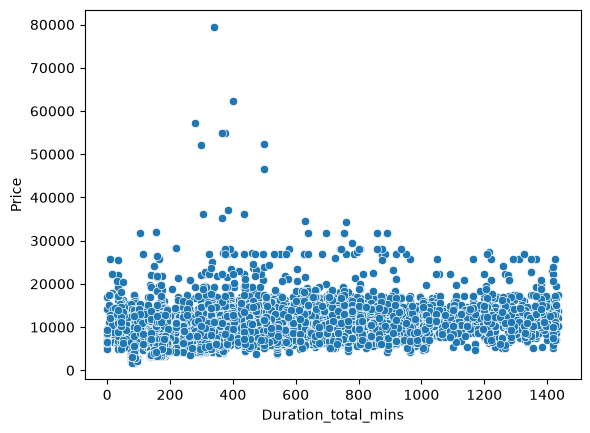

In [45]:
sns.scatterplot(data = data, x = 'Duration_total_mins', y = 'Price')

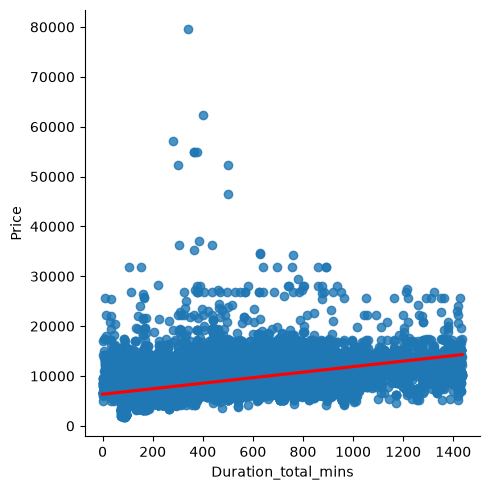

In [46]:
sns.lmplot(data = data, x = 'Duration_total_mins', y = 'Price', line_kws = {'color' : 'red'})

In [47]:
m , c = np.polyfit(data["Duration_total_mins"],data['Price'],1)

In [48]:
m

np.float64(5.535752729771956)

In [49]:
c

np.float64(6345.852544716875)

## Applying One-hot Encoding on data

In [50]:
df = data.copy()

In [51]:
data.dtypes

Airline                  str
Source                   str
Destination              str
Route                    str
Total_Stops              str
Additional_Info          str
Price                  int64
Journey_Day            int32
Journey_Month          int32
Journey_Year           int32
Dep_Time_hour          int32
Dep_Time_minute        int32
Arrival_Time_hour      int32
Arrival_Time_minute    int32
Duration_hour          int64
Duration_minute        int64
Duration_total_mins    int64
dtype: object

In [52]:
cat_col = [col for col in data.columns if data[col].dtype == "str"]

In [53]:
num_col = [col for col in data.columns if data[col].dtype != "str"]

In [54]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [55]:
data['Source'].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [56]:
source_dummies = pd.get_dummies(data['Source'], prefix = "Source").astype(int)

In [57]:
source_dummies

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0
...,...,...,...,...,...
10678,0,0,0,1,0
10679,0,0,0,1,0
10680,1,0,0,0,0
10681,1,0,0,0,0


In [58]:
data = pd.concat([data , source_dummies] , axis=1)

In [59]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,...,1,10,2,50,170,1,0,0,0,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,...,13,15,7,25,445,0,0,0,1,0


### Target Guided Encoding

In [60]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [61]:
data["Airline"].nunique()

12

In [62]:
data["Airline"].unique()

<StringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

In [63]:
data.groupby(["Airline"])["Price"].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4335.841718
Air Asia                              5590.260188
IndiGo                                5668.469897
GoAir                                 5861.056701
Vistara                               7801.355649
Vistara Premium economy               8962.333333
Air India                             9556.608028
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11599.021081
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [64]:
airlines = data.groupby(["Airline"])["Price"].mean().sort_values().index
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='str', name='Airline')

In [65]:
numbers = range(len(airlines))

In [66]:
dict_airlines = dict(zip(airlines,numbers))

In [67]:
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [68]:
data["Airline"] = data["Airline"].map(dict_airlines)
data["Airline"]

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10462, dtype: int64

In [69]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [70]:
data["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [71]:
data["Destination"].replace("New Delhi" , "Delhi", inplace = True)

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\2333635423.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["Destination"].replace("New Delhi" , "Delhi", inplace = True)


0           Delhi
1        Banglore
2          Cochin
3        Banglore
4           Delhi
           ...   
10678    Banglore
10679    Banglore
10680       Delhi
10681       Delhi
10682      Cochin
Name: Destination, Length: 10462, dtype: str

In [72]:
data["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [73]:
Destination = data.groupby(["Destination"])["Price"].mean().sort_values().index
Destination

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin', 'New Delhi'], dtype='str', name='Destination')

In [74]:
dict_dest = dict(zip(Destination , range(len(Destination))))
dict_dest

{'Kolkata': 0,
 'Hyderabad': 1,
 'Delhi': 2,
 'Banglore': 3,
 'Cochin': 4,
 'New Delhi': 5}

In [75]:
data["Destination"] = data["Destination"].map(dict_dest)
data["Destination"] 

0        5
1        3
2        4
3        3
4        5
        ..
10678    3
10679    3
10680    2
10681    5
10682    4
Name: Destination, Length: 10462, dtype: int64

### Label Encoding

In [76]:
data["Total_Stops"]

0        non-stop
1         2 stops
2         2 stops
3          1 stop
4          1 stop
           ...   
10678    non-stop
10679    non-stop
10680    non-stop
10681    non-stop
10682     2 stops
Name: Total_Stops, Length: 10462, dtype: str

In [77]:
stop = {'non-stop' : 0, '2 stops' : 2, '1 stop' : 1, '3 stops' : 3, '4 stops' : 4}

In [78]:
data["Total_Stops"] = data["Total_Stops"].map(stop)


In [79]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,3,Banglore,5,BLR → DEL,0,No info,3897,24,3,2019,...,1,10,2,50,170,1,0,0,0,0
1,7,Kolkata,3,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,...,13,15,7,25,445,0,0,0,1,0


In [80]:
data["Additional_Info"].value_counts()/len(data)*100

Additional_Info
No info                         78.206844
In-flight meal not included     18.409482
No check-in baggage included     3.039572
1 Long layover                   0.181610
Change airports                  0.066909
Business class                   0.038234
No Info                          0.028675
1 Short layover                  0.009558
Red-eye flight                   0.009558
2 Long layover                   0.009558
Name: count, dtype: float64

In [81]:
data["Journey_Year"].unique()

array([2019], dtype=int32)

In [82]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Duration_hour', 'Duration_minute',
       'Duration_total_mins', 'Source_Banglore', 'Source_Chennai',
       'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai'],
      dtype='str')

In [83]:
columns = ['Additional_Info','Route','Journey_Year','Source','Duration_total_mins']

In [84]:
data.drop(columns = columns, inplace = True)

In [85]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_Day',
       'Journey_Month', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_minute', 'Source_Banglore', 'Source_Chennai', 'Source_Delhi',
       'Source_Kolkata', 'Source_Mumbai'],
      dtype='str')

## Outliers Detection

In [86]:
def plot(df, col):
    fig , (ax1 , ax2 , ax3) = plt.subplots(3 , 1)

    sns.distplot(df[col] , ax = ax1)
    sns.boxplot(data = df , x = col , ax = ax2)
    sns.distplot(df[col], ax= ax3, kde = False)

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\491483083.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col] , ax = ax1)
C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\491483083.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax= ax3, kde = False)


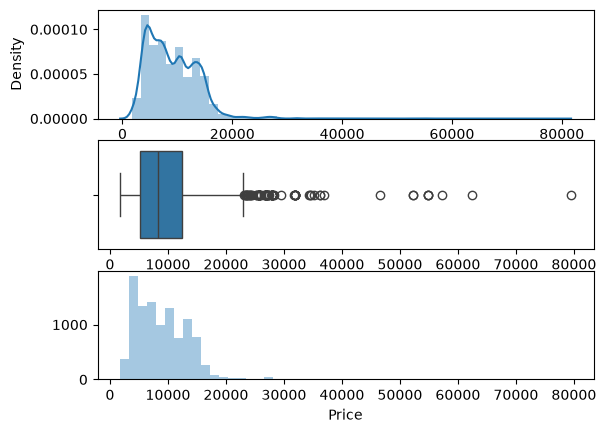

In [87]:
plot(data , "Price")

In [88]:
q1 = data["Price"].quantile(0.25)
q3 = data["Price"].quantile(0.75)

In [89]:
iqr = q3 - q1
iqr

np.float64(7120.75)

In [90]:
maxi = q3 + 1.5*iqr
mini = q1 - 1.5*iqr

In [91]:
maxi

np.float64(23025.875)

In [92]:
mini

np.float64(-5457.125)

In [93]:
out_prices = [price for price in data["Price"] if price > maxi or price < mini]
out_prices

[27430,
 36983,
 26890,
 26890,
 25139,
 27210,
 52229,
 26743,
 26890,
 25735,
 27992,
 26890,
 26890,
 23583,
 26890,
 23533,
 24115,
 25735,
 54826,
 31783,
 27992,
 26890,
 26890,
 25430,
 36235,
 27210,
 26890,
 25735,
 54826,
 26890,
 35185,
 79512,
 28097,
 27992,
 26890,
 25735,
 26092,
 31825,
 25913,
 25735,
 27992,
 31825,
 23267,
 62427,
 54826,
 31825,
 25430,
 26890,
 36235,
 23843,
 26890,
 25735,
 28322,
 25735,
 25735,
 31825,
 26890,
 27992,
 34273,
 46490,
 29528,
 26890,
 26890,
 26890,
 34503,
 26890,
 27992,
 26890,
 26890,
 23170,
 24528,
 26890,
 27992,
 25735,
 34608,
 25703,
 26890,
 23528,
 31825,
 27282,
 25735,
 27992,
 52285,
 24017,
 31945,
 26890,
 24318,
 23677,
 27992,
 24210,
 57209,
 26890,
 31825,
 26480]

In [94]:
len(out_prices)

94

In [95]:
data["Price"] = np.where(data["Price"]>=30000 , data["Price"].median(), data["Price"])

C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\491483083.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col] , ax = ax1)
C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\491483083.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax= ax3, kde = False)


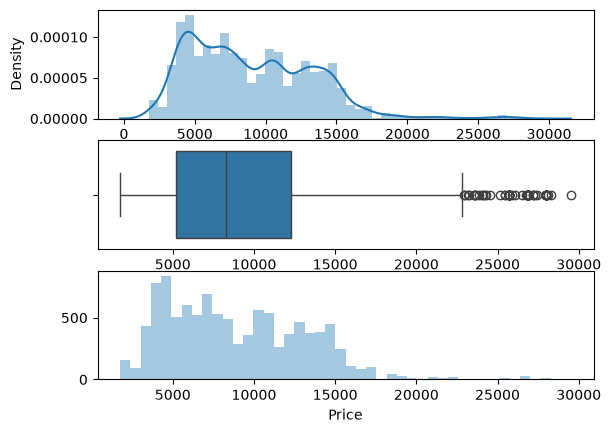

In [96]:
plot(data , "Price")

## Feature Selection

In [97]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_Day',
       'Journey_Month', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hour',
       'Duration_minute', 'Source_Banglore', 'Source_Chennai', 'Source_Delhi',
       'Source_Kolkata', 'Source_Mumbai'],
      dtype='str')

In [98]:
x = data.drop(["Price"], axis = 1)

In [99]:
y = data["Price"]

In [100]:
from sklearn.ensemble import RandomForestRegressor

In [101]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [102]:
rf.fit(x , y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [103]:
rf.feature_importances_

array([0.17120954, 0.01873612, 0.4478831 , 0.11140793, 0.07244192,
       0.03065795, 0.02437854, 0.0308262 , 0.01892511, 0.03186244,
       0.02032302, 0.00431515, 0.00078028, 0.00446356, 0.00648302,
       0.00530612])

In [104]:
x.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Journey_Day', 'Journey_Month',
       'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='str')

In [105]:
pd.DataFrame({
    "Feature" : x.columns,
    "Importance" : rf.feature_importances_
}).sort_values(by = "Importance" , ascending = False)

,Feature,Importance
2,Total_Stops,0.447883
0,Airline,0.171210
3,Journey_Day,0.111408
4,Journey_Month,0.072442
9,Duration_hour,0.031862
7,Arrival_Time_hour,0.030826
5,Dep_Time_hour,0.030658
6,Dep_Time_minute,0.024379
10,Duration_minute,0.020323
8,Arrival_Time_minute,0.018925


## Build ML model

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [108]:
from sklearn.ensemble import RandomForestRegressor

In [109]:
ml_model = RandomForestRegressor()

In [110]:
ml_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [111]:
y_pred = ml_model.predict(X_test)

In [112]:
y_pred

array([15624.25833333,  3837.75333333,  4290.65933333, ...,
       13847.3325    , 11598.78366667,  4043.91333333], shape=(2616,))

In [113]:
from sklearn import metrics

In [114]:
metrics.mean_absolute_error(y_test , y_pred)

1175.0328101089256

In [115]:
metrics.mean_absolute_percentage_error(y_test , y_pred)*100

13.431427551909087

In [116]:
metrics.r2_score(y_test , y_pred)

0.8141779930285852

In [117]:
import pickle

In [118]:
with open(r"C:\22134028  SUSHANK\Flight fare\rd_random.pkl", "wb") as file:
    pickle.dump(ml_model , file)

In [119]:
model = open(r"C:\22134028  SUSHANK\Flight fare\rd_random.pkl" , "rb")

In [120]:
rf_random = pickle.load(model)

In [121]:
y_pred2 = rf_random.predict(X_test)

In [122]:
metrics.r2_score(y_test , y_pred2)

0.8141779930285852

## Using Various ML algos !

In [123]:
def predict(ml_model):
    model = ml_model.fit(X_train , y_train)
    print("Training Score : {}".format(model.score(X_train,y_train)))

    y_prediction = model.predict(X_test)
    print("Pridictions are : {}".format(y_prediction))

    print('\n')
    r2_score = metrics.r2_score(y_test , y_prediction)
    print("r2_score : {}".format(r2_score))
    print("MAE : {}".format(metrics.mean_absolute_error(y_test , y_prediction)))
    print("MAPE : {}".format(metrics.mean_absolute_percentage_error(y_test , y_prediction)))
    sns.distplot(y_test - y_prediction)

Training Score : 0.9509636307561657
Pridictions are : [15577.8885      3844.46666667  4261.4        ... 13748.0465
 11645.68816667  4075.98666667]


r2_score : 0.8114309847860248
MAE : 1174.570529474242
MAPE : 0.13425341646528247


C:\Users\Sushank Yadav\AppData\Local\Temp\ipykernel_4900\3964575782.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - y_prediction)


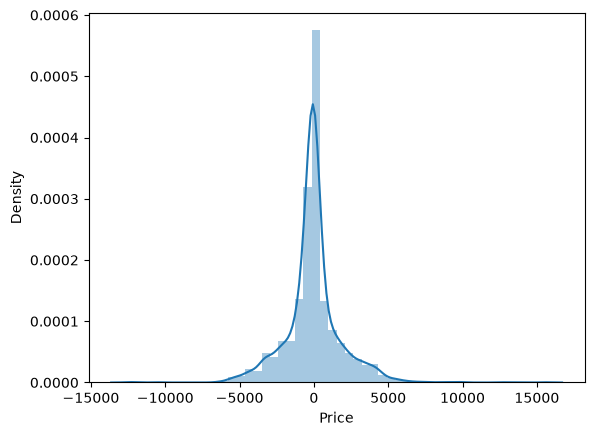

In [124]:
predict(RandomForestRegressor())